# Vision Transformer (ViT), Step by Step (PyTorch)

> The objective here is to learn the building blocks of Transformer-based architecture in computer vision problems and how to implement them in PyTorch. The ViT architecture: [paper](https://arxiv.org/abs/2010.11929).

This lab has three parts:
1. **Step-by-step implementation** of the ViT architecture from scratch
2. **Application** of this ViT to the same 8-class clothing dataset used in the earlier multi-class CNN lab
3. **Comparison** with a CNN trained from scratch on the exact same data

# Learning Objectives

By the end of this lab, you should be able to:

- explain the five main steps of the ViT architecture: patchify, patch embedding, position embedding + class token, Transformer encoder, MLP head
- implement patch extraction from an image using tensor reshaping (no built-in "extract_patches" op in PyTorch)
- implement a Transformer encoder block with self-attention, exactly as used in ViT (no causal mask needed here — image patches are not a sequence with a "past" and "future")
- build a full Vision Transformer for image classification, from scratch
- train it and compare it against a CNN trained from scratch, on the same dataset

## Overview

As described in the paper [arxiv.org](https://arxiv.org/abs/2010.11929), ViT works as follows:

1. Each image is split into fixed-size patches
2. Calculate a Patch Embedding for each patch
3. Add position embeddings and a class token to the Patch Embeddings
4. The sequence of embeddings is passed to a Transformer encoder
5. Pass the representation through an MLP Head to get final class predictions

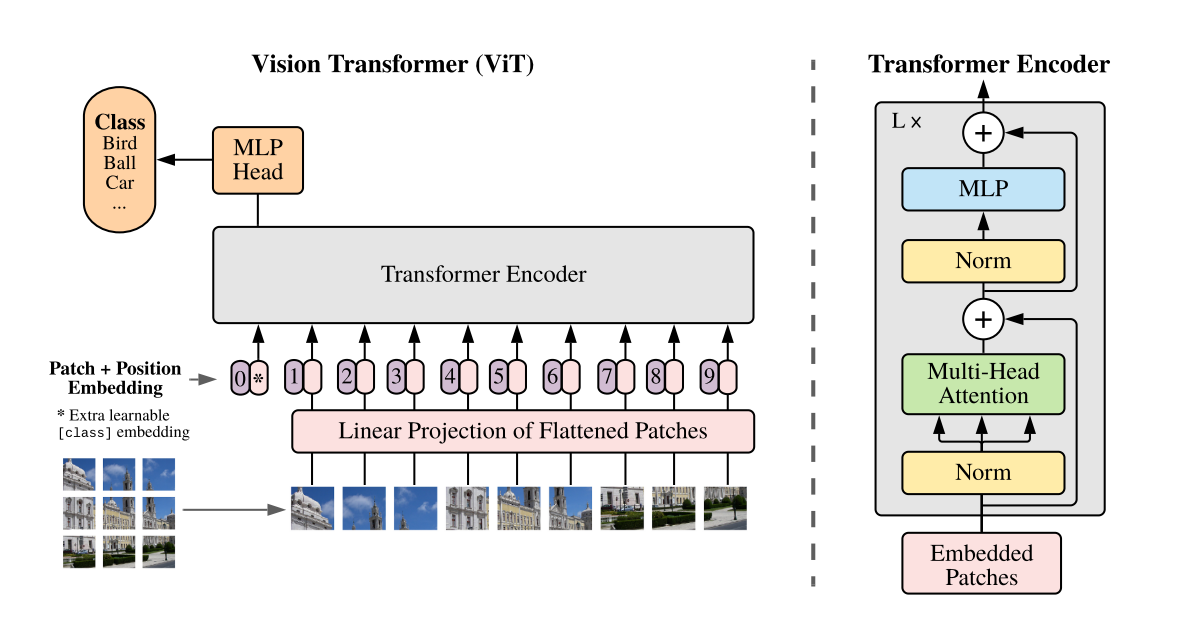

As a detailed example, when trying to classify an image (with a similar size to ImageNet images: `224 x 224 x 3`), the process is as follows:

First, divide the image into patches of size `16 x 16`. This creates `14 x 14 = 196` patches.

Second, pass each patch through a linear layer to get a **Patch Embedding** vector of size `1 x 768` (note that `3 x 16 x 16 = 768`).

Third, for each patch we calculate its **Position Embedding**, add it to the Patch Embedding, and append the embedding of a special `[class]` token.

After this, we end up with a matrix of size `197 x 768` (`196` patches `+ 1` class token).

Fourth, the embeddings are passed through a **Transformer Encoder**.

Fifth, the resulting representation is passed through an `MLP Head` (a simple linear layer) to generate the class predictions.

## Implementation

As described above, the ViT model consists of a patch embedding, multiple Transformer blocks with self-attention, and a multilayer perceptron.

**A note on this PyTorch port:** the original notebook used `tf.image.extract_patches`, a Keras `Input`/functional-API model, and `keras.layers.MultiHeadAttention`. PyTorch has no built-in "extract patches" operation, so we implement it with `Tensor.unfold`; the rest translates fairly directly to `nn.Module` subclasses.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(42)
np.random.seed(42)

PyTorch version: 2.11.0+cu128
Using device: cuda


### Patch extraction

The first step in implementing the ViT model is extracting patches from an input image.

In PyTorch, there is no direct equivalent of `tf.image.extract_patches`. We instead use `Tensor.unfold`, which slides a window across a dimension and stacks the results — applied twice (once for height, once for width) it extracts non-overlapping `patch_size x patch_size` blocks. We wrap this in an `nn.Module` so it plugs into the rest of the model just like any other layer.

In [ ]:
class PatchExtractor(nn.Module):
    def __init__(self, patch_size=16):
        super().__init__()
        self.patch_size = patch_size

    def forward(self, images):
        # images: (batch, channels, H, W)
        p = self.patch_size
        batch_size, channels, H, W = images.shape
        assert H % p == 0 and W % p == 0, "Image size must be divisible by patch_size"

        patches = images.unfold(2, p, p).unfold(3, p, p)          # (batch, C, H/p, W/p, p, p)
        patches = patches.permute(0, 2, 3, 1, 4, 5).contiguous()   # (batch, H/p, W/p, C, p, p)
        patches = patches.view(batch_size, -1, channels * p * p)    # (batch, num_patches, C*p*p)
        return patches

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

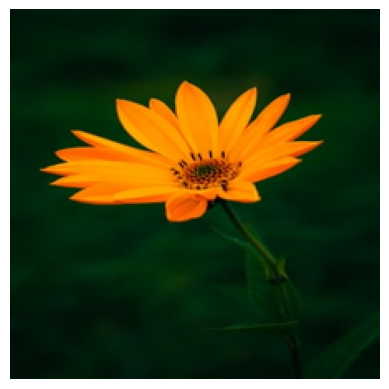

In [ ]:
# Download a sample image (works out of the box on Colab; if this fails offline, replace
# it with any local JPEG and adjust the path below).
!curl -s -o flower.jpeg "https://images.unsplash.com/photo-1604085572504-a392ddf0d86a?ixlib=rb-1.2.1&ixid=MnwxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8&auto=format&fit=crop&w=224&q=224"

image = plt.imread("flower.jpeg")
image_resized = np.array(
    __import__("PIL").Image.fromarray(image).resize((224, 224))
)
plt.imshow(image_resized)
plt.axis("off")

For an image of size `(224, 224)` we get `196` patches of `16x16`.

In [ ]:
# (batch, C, H, W), normalized to [0, 1] like the rest of this course's labs
image_tensor = torch.tensor(image_resized / 255.0, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)

patch_extractor = PatchExtractor(patch_size=16)
patches = patch_extractor(image_tensor)
patches.shape

torch.Size([1, 196, 768])

We can visualize all 196 patches.

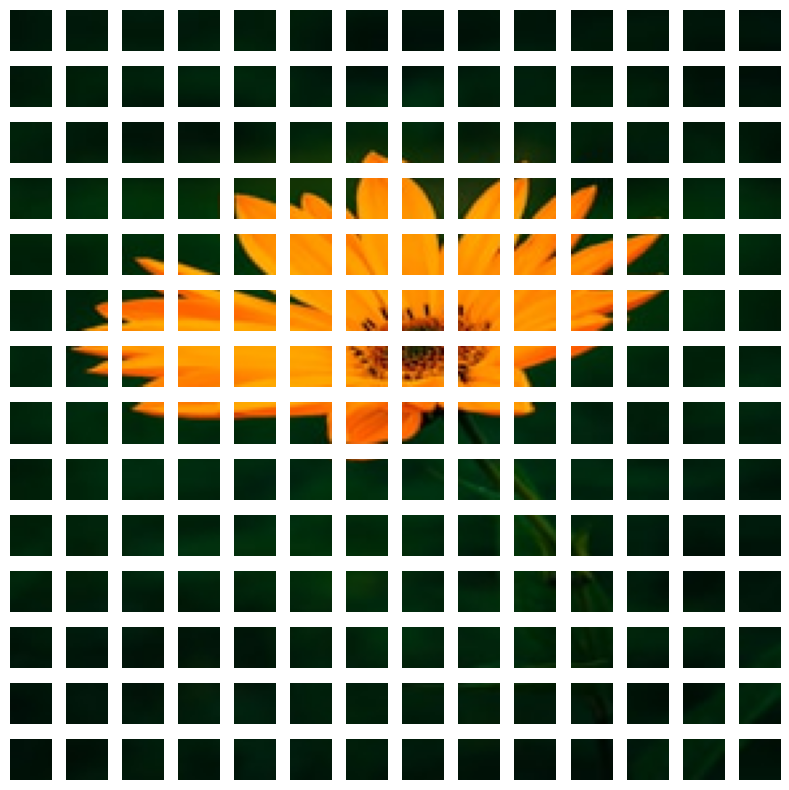

In [ ]:
n = int(np.sqrt(patches.shape[1]))
plt.figure(figsize=(8, 8))
for i in range(patches.shape[1]):
    ax = plt.subplot(n, n, i + 1)
    patch_img = patches[0, i].view(3, 16, 16).permute(1, 2, 0).numpy()
    ax.imshow(patch_img)
    ax.axis("off")
plt.tight_layout()
plt.show()

### Patch Encoding

The Patch Encoder takes the extracted patches and generates their embeddings, which are later fed to the Transformer. For each patch, it also creates a positional embedding.

The `PatchEncoder` needs:
- a `Linear` layer to project a flattened patch into a vector of size `projection_dim`
- an `Embedding` layer to learn the positional embeddings
- a trainable class-token parameter (`nn.Parameter`, PyTorch's equivalent of a trainable `tf.Variable`)

**A note on token order:** the original notebook concatenates the patch embeddings *first* and the class token *last* (`[patch_1, ..., patch_196, class_token]`), unlike the ViT paper's usual convention of prepending the class token at position 0. We keep this exact order for fidelity — it makes no functional difference here since (as you'll see in the full model below) we average over *all* tokens rather than reading out the class token specifically, so its position in the sequence doesn't matter.

**A PyTorch note on shapes:** Keras's `Dense`/`Embedding` layers infer their input size automatically the first time they're called. In PyTorch, `nn.Linear` needs the input dimension declared up front (`patch_dim` below) — a difference worth remembering any time you port a Keras layer over.

In [ ]:
class PatchEncoder(nn.Module):
    def __init__(self, num_patches, projection_dim, patch_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection_dim = projection_dim

        self.class_token = nn.Parameter(torch.randn(1, 1, projection_dim) * 0.02)
        self.projection = nn.Linear(patch_dim, projection_dim)
        self.position_embedding = nn.Embedding(num_patches + 1, projection_dim)

    def forward(self, patch):
        batch_size = patch.shape[0]

        # Calculate patch embeddings
        patches_embed = self.projection(patch)                              # (batch, num_patches, projection_dim)
        class_token = self.class_token.expand(batch_size, -1, -1)            # (batch, 1, projection_dim)
        patches_embed = torch.cat([patches_embed, class_token], dim=1)       # (batch, num_patches + 1, projection_dim)

        # Calculate positional embeddings
        positions = torch.arange(self.num_patches + 1, device=patch.device)
        positions_embed = self.position_embedding(positions)                 # (num_patches + 1, projection_dim)

        # Add both embeddings (broadcasts over the batch dimension)
        return patches_embed + positions_embed

We can confirm the output of this layer is as expected: `1, 197, 768`.

In [ ]:
patch_encoder = PatchEncoder(num_patches=196, projection_dim=768, patch_dim=3 * 16 * 16)
embeddings = patch_encoder(patches)
embeddings.shape

torch.Size([1, 197, 768])

### Multilayer Perceptron

An MLP consists of two dense layers and a `GELU` activation. It's used both inside the Transformer encoder and as the final output layer of the ViT model.

In [ ]:
class MLP(nn.Module):
    def __init__(self, in_features, hidden_features, out_features, dropout_rate=0.1):
        super().__init__()
        self.dense1 = nn.Linear(in_features, hidden_features)
        self.dense2 = nn.Linear(hidden_features, out_features)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        x = F.gelu(self.dense1(x))
        x = self.dropout(x)
        x = self.dense2(x)
        y = self.dropout(x)
        return y

In [ ]:
mlp = MLP(in_features=768, hidden_features=768 * 2, out_features=768)
y = mlp(torch.zeros(1, 197, 768))
y.shape

torch.Size([1, 197, 768])

### Transformer Encoder

The Transformer encoder is a sequence of `L` identical blocks. We implement the block once and stack it `L` times.

The block uses `LayerNorm` and multi-head self-attention, plus residual (skip) connections.

**No causal mask here:** unlike the text-generation labs, a ViT block lets every patch attend to every other patch freely — an image has no "past" or "future" to hide, so full (non-causal) self-attention is exactly what we want.

In [ ]:
class Block(nn.Module):
    def __init__(self, projection_dim, num_heads=4, dropout_rate=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(projection_dim, eps=1e-6)
        self.attn = nn.MultiheadAttention(projection_dim, num_heads, dropout=dropout_rate, batch_first=True)
        self.norm2 = nn.LayerNorm(projection_dim, eps=1e-6)
        self.mlp = MLP(projection_dim, projection_dim * 2, projection_dim, dropout_rate)

    def forward(self, x):
        # Layer normalization 1
        x1 = self.norm1(x)
        # Multi-head self-attention (no mask: every patch can attend to every other patch)
        attention_output, _ = self.attn(x1, x1, x1, need_weights=False)
        # Skip connection 1
        x2 = attention_output + x
        # Layer normalization 2
        x3 = self.norm2(x2)
        # MLP
        x3 = self.mlp(x3)
        # Skip connection 2
        y = x3 + x2
        return y

In [ ]:
block = Block(projection_dim=768)
y = block(torch.zeros(1, 197, 768))
y.shape

torch.Size([1, 197, 768])

Now we can stack the `Block` layer `num_blocks` times to build the full Transformer encoder.

In [ ]:
class TransformerEncoder(nn.Module):
    def __init__(self, projection_dim, num_heads=4, num_blocks=12, dropout_rate=0.1):
        super().__init__()
        self.blocks = nn.ModuleList([
            Block(projection_dim, num_heads, dropout_rate) for _ in range(num_blocks)
        ])
        self.norm = nn.LayerNorm(projection_dim, eps=1e-6)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        y = self.dropout(x)
        return y

In [ ]:
transformer = TransformerEncoder(projection_dim=768)
y = transformer(embeddings)
y.shape

torch.Size([1, 197, 768])

## Putting it Together

After defining all the major components, we combine them: patch extractor → patch encoder → Transformer encoder → MLP head.

**Note:** we compute `num_patches` automatically from `image_size` and `patch_size`, with an assertion that catches a mismatched image size immediately instead of silently producing a shape error deep inside the model.

**Also note:** we use global average pooling over *all* tokens (patches + class token) for the final classification, rather than reading out only the class token's representation — a common simplification, though not what the original ViT paper does. You're welcome to try extracting just the class token instead as an exercise (see Final Questions).

In [ ]:
class VisionTransformer(nn.Module):
    def __init__(self, num_classes, image_size=224, patch_size=16, projection_dim=768,
                 in_channels=3, num_heads=4, num_blocks=12, dropout_rate=0.1):
        super().__init__()
        assert image_size % patch_size == 0, "image_size must be divisible by patch_size"
        num_patches = (image_size // patch_size) ** 2
        patch_dim = in_channels * patch_size * patch_size

        self.patch_extractor = PatchExtractor(patch_size)
        self.patch_encoder = PatchEncoder(num_patches, projection_dim, patch_dim)
        self.transformer_encoder = TransformerEncoder(projection_dim, num_heads, num_blocks, dropout_rate)
        self.mlp_head = MLP(projection_dim, projection_dim, num_classes, dropout_rate=0.5)

    def forward(self, images):
        patches = self.patch_extractor(images)
        embed = self.patch_encoder(patches)
        representation = self.transformer_encoder(embed)
        representation = representation.mean(dim=1)  # GlobalAveragePooling1D equivalent
        logits = self.mlp_head(representation)
        return logits


vit_demo = VisionTransformer(num_classes=2).to(device)
total_params = sum(p.numel() for p in vit_demo.parameters())
print(vit_demo)
print(f"Total parameters: {total_params:,}")

VisionTransformer(
  (patch_extractor): PatchExtractor()
  (patch_encoder): PatchEncoder(
    (projection): Linear(in_features=768, out_features=768, bias=True)
    (position_embedding): Embedding(197, 768)
  )
  (transformer_encoder): TransformerEncoder(
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLP(
          (dense1): Linear(in_features=768, out_features=1536, bias=True)
          (dense2): Linear(in_features=1536, out_features=768, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
    (dropout): Dropout(p=0.5, inplace=False)
  )
  (mlp_head): MLP(
    (dense1): Linear(in_fea

# Part 2 — Apply the ViT to a Real Dataset

We now train this ViT architecture on the **same 8-class clothing dataset** used in the earlier multi-class CNN lab (`accessories, jackets, jeans, knitwear, shirts, shoes, shorts, tees`), so we can make a direct, fair comparison with the CNN-from-scratch baseline from that lab.

Following the original notebook's note, we resize images down to `64x64` to keep memory and training time manageable — with a Transformer trained from scratch on a fairly small dataset, this also happens to be a more realistic setting than the full `224x224` ImageNet-scale configuration used in Part 1's walkthrough.

In [ ]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from zipfile import ZipFile
file_name = "/content/drive/MyDrive/AIM/TPs/Data_TP/data_clothes.zip"

with ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall("data_clothes")
    print('Done')

Done


We reuse the exact same `ImageFolder` + `DataLoader` pattern as the earlier multi-class CNN lab, for consistency (the original ViT tutorial used a hand-written folder-walking function instead; `ImageFolder` is simpler and less error-prone).

In [ ]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

base_dir = "data_clothes"
train_dir = os.path.join(base_dir, "train")
validation_dir = os.path.join(base_dir, "valid")
test_dir = os.path.join(base_dir, "test")

image_size = 64
batch_size = 16

basic_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(train_dir, transform=basic_transform)
validation_dataset = datasets.ImageFolder(validation_dir, transform=basic_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=basic_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

class_names = train_dataset.classes
num_classes = len(class_names)
print("Classes:", class_names)
print("Train / Val / Test sizes:", len(train_dataset), len(validation_dataset), len(test_dataset))

Classes: ['accessories', 'jackets', 'jeans', 'knitwear', 'shirts', 'shoes', 'shorts', 'tees']
Train / Val / Test sizes: 3467 382 8


# Vision Transformer for the Clothing Dataset

Matching the original notebook's configuration for this dataset: `64x64` images, `patch_size=8` (so `8x8=64` patches), `projection_dim=64`.

Note: the original notebook used num_blocks=12 (the full "ViT-Base" depth) here, copied over unchanged from the Part 1 walkthrough. That depth is designed for pretraining on huge datasets (ImageNet-21k) -- for a small dataset trained from scratch, it mostly means much slower training without a real accuracy benefit,and a higher risk of overfitting. We reduce it to 4 blocks, which trains noticeably faster while keeping the architecture (and the comparison with the CNN baseline) meaningful.

In [ ]:
vit_model = VisionTransformer(
    num_classes=num_classes,
    image_size=64,
    patch_size=8,
    projection_dim=64,
    num_heads=4,
    num_blocks=4,
    dropout_rate=0.1,
).to(device)

vit_total_params = sum(p.numel() for p in vit_model.parameters())
print(f"ViT total parameters: {vit_total_params:,}")

ViT total parameters: 155,272


# Model Training

**Note:** we reuse the training utilities (with early stopping and a learning-rate scheduler) established in the earlier multi-class CNN lab, instead of a fixed `epochs=40` with no early stopping — this also makes the comparison with the CNN baseline more directly comparable, since both models are now trained under identical conditions.

In [ ]:
import copy

def evaluate_classifier(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for xb, yb in data_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            total_loss += loss.item() * xb.size(0)
            preds = torch.argmax(logits, dim=1)
            correct += (preds == yb).sum().item()
            total += xb.size(0)
    return total_loss / total, correct / total


def train_with_early_stopping(model, train_loader, val_loader, device, epochs=40, patience=8, lr=1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

    history = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            correct += (torch.argmax(logits, dim=1) == yb).sum().item()
            total += xb.size(0)

        train_loss, train_acc = running_loss / total, correct / total
        val_loss, val_acc = evaluate_classifier(model, val_loader, criterion, device)

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} - loss: {train_loss:.4f} - accuracy: {train_acc:.4f} "
              f"- val_loss: {val_loss:.4f} - val_accuracy: {val_acc:.4f}")

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"Early stopping triggered after epoch {epoch+1}.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history


import time

print("=== Training ViT from scratch ===")
start_time = time.time()
vit_history = train_with_early_stopping(vit_model, train_loader, validation_loader, device, epochs=40, patience=8)
vit_train_time = time.time() - start_time
print(f"ViT training time: {vit_train_time:.2f} seconds")

=== Training ViT from scratch ===
Epoch 1/40 - loss: 1.8556 - accuracy: 0.2714 - val_loss: 1.2537 - val_accuracy: 0.6126
Epoch 2/40 - loss: 1.5424 - accuracy: 0.3784 - val_loss: 1.0562 - val_accuracy: 0.6545
Epoch 3/40 - loss: 1.4265 - accuracy: 0.3998 - val_loss: 0.9188 - val_accuracy: 0.6990
Epoch 4/40 - loss: 1.3576 - accuracy: 0.4370 - val_loss: 0.9184 - val_accuracy: 0.6806
Epoch 5/40 - loss: 1.3503 - accuracy: 0.4329 - val_loss: 0.8192 - val_accuracy: 0.7356
Epoch 6/40 - loss: 1.3089 - accuracy: 0.4546 - val_loss: 0.7904 - val_accuracy: 0.7356
Epoch 7/40 - loss: 1.3243 - accuracy: 0.4329 - val_loss: 0.7829 - val_accuracy: 0.7513
Epoch 8/40 - loss: 1.3055 - accuracy: 0.4468 - val_loss: 0.8100 - val_accuracy: 0.7356
Epoch 9/40 - loss: 1.2877 - accuracy: 0.4566 - val_loss: 0.7748 - val_accuracy: 0.7435
Epoch 10/40 - loss: 1.2702 - accuracy: 0.4514 - val_loss: 0.7073 - val_accuracy: 0.7565
Epoch 11/40 - loss: 1.2471 - accuracy: 0.4727 - val_loss: 0.7114 - val_accuracy: 0.7513
Epoch 1

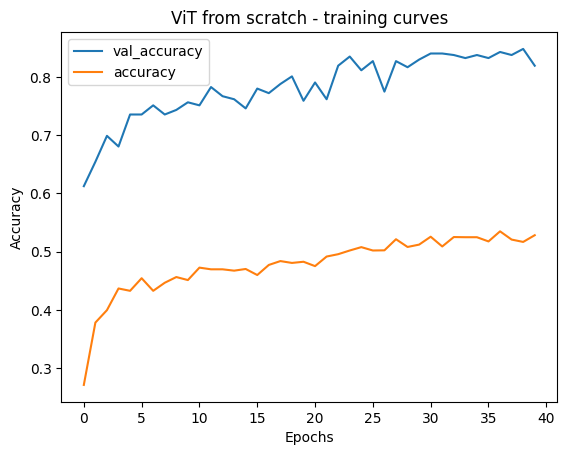

In [ ]:
plt.plot(vit_history["val_accuracy"], label="val_accuracy")
plt.plot(vit_history["accuracy"], label="accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("ViT from scratch - training curves")
plt.legend()
plt.show()

## CNN-Based Model (From Scratch)

For a fair comparison, we reuse the **exact same** `BaselineCNN` architecture from the earlier multi-class CNN lab, trained under the exact same procedure as the ViT above.

In [ ]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 64, kernel_size=3), nn.ReLU(),
        )
        # With 64x64 input: 64 -> 31 -> 14(pool) -> ... matches the original Sequential CNN's shapes
        with torch.no_grad():
            dummy = torch.zeros(1, 3, 64, 64)
            flat_dim = self.features(dummy).flatten(1).shape[1]

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


cnn_model = BaselineCNN(num_classes).to(device)
cnn_total_params = sum(p.numel() for p in cnn_model.parameters())
print(cnn_model)
print(f"CNN total parameters: {cnn_total_params:,}")

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=9216, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=8, bias=True)
  )
)
CNN total parameters: 646,728


In [ ]:
print("=== Training CNN from scratch ===")
start_time = time.time()
cnn_history = train_with_early_stopping(cnn_model, train_loader, validation_loader, device, epochs=40, patience=8)
cnn_train_time = time.time() - start_time
print(f"CNN training time: {cnn_train_time:.2f} seconds")

=== Training CNN from scratch ===
Epoch 1/40 - loss: 1.0544 - accuracy: 0.6265 - val_loss: 0.6718 - val_accuracy: 0.7827
Epoch 2/40 - loss: 0.5279 - accuracy: 0.7990 - val_loss: 0.4596 - val_accuracy: 0.8115
Epoch 3/40 - loss: 0.4139 - accuracy: 0.8480 - val_loss: 0.4253 - val_accuracy: 0.8613
Epoch 4/40 - loss: 0.3564 - accuracy: 0.8670 - val_loss: 0.4130 - val_accuracy: 0.8377
Epoch 5/40 - loss: 0.3109 - accuracy: 0.8815 - val_loss: 0.3019 - val_accuracy: 0.8874
Epoch 6/40 - loss: 0.2601 - accuracy: 0.9019 - val_loss: 0.2795 - val_accuracy: 0.9136
Epoch 7/40 - loss: 0.2233 - accuracy: 0.9172 - val_loss: 0.2485 - val_accuracy: 0.9162
Epoch 8/40 - loss: 0.1947 - accuracy: 0.9204 - val_loss: 0.2594 - val_accuracy: 0.9136
Epoch 9/40 - loss: 0.1687 - accuracy: 0.9363 - val_loss: 0.2888 - val_accuracy: 0.8979
Epoch 10/40 - loss: 0.1487 - accuracy: 0.9475 - val_loss: 0.2800 - val_accuracy: 0.9084
Epoch 11/40 - loss: 0.1271 - accuracy: 0.9513 - val_loss: 0.2912 - val_accuracy: 0.9084
Epoch 1

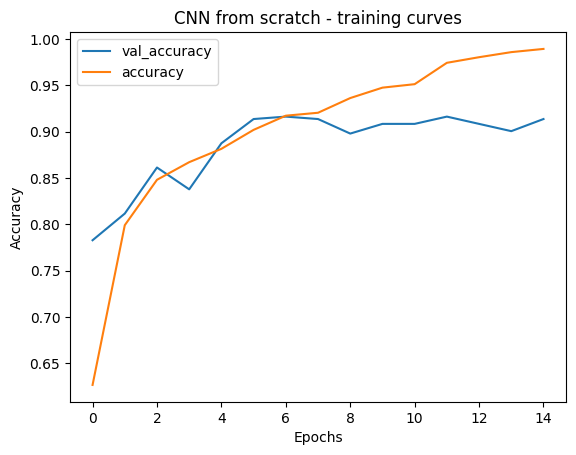

In [ ]:
plt.plot(cnn_history["val_accuracy"], label="val_accuracy")
plt.plot(cnn_history["accuracy"], label="accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("CNN from scratch - training curves")
plt.legend()
plt.show()

# Part 3 — Compare ViT vs. CNN (Both From Scratch)

In [ ]:
import pandas as pd

criterion = nn.CrossEntropyLoss()
vit_test_loss, vit_test_acc = evaluate_classifier(vit_model, test_loader, criterion, device)
cnn_test_loss, cnn_test_acc = evaluate_classifier(cnn_model, test_loader, criterion, device)

comparison = pd.DataFrame([
    {"Model": "ViT (scratch)", "Parameters": vit_total_params, "Training time (s)": vit_train_time,
     "Test accuracy": vit_test_acc, "Best val_accuracy": max(vit_history["val_accuracy"])},
    {"Model": "CNN (scratch)", "Parameters": cnn_total_params, "Training time (s)": cnn_train_time,
     "Test accuracy": cnn_test_acc, "Best val_accuracy": max(cnn_history["val_accuracy"])},
])
comparison

,Model,Parameters,Training time (s),Test accuracy,Best val_accuracy
0,ViT (scratch),155272,482.838553,0.125,0.848168
1,CNN (scratch),646728,154.706825,0.250,0.916230


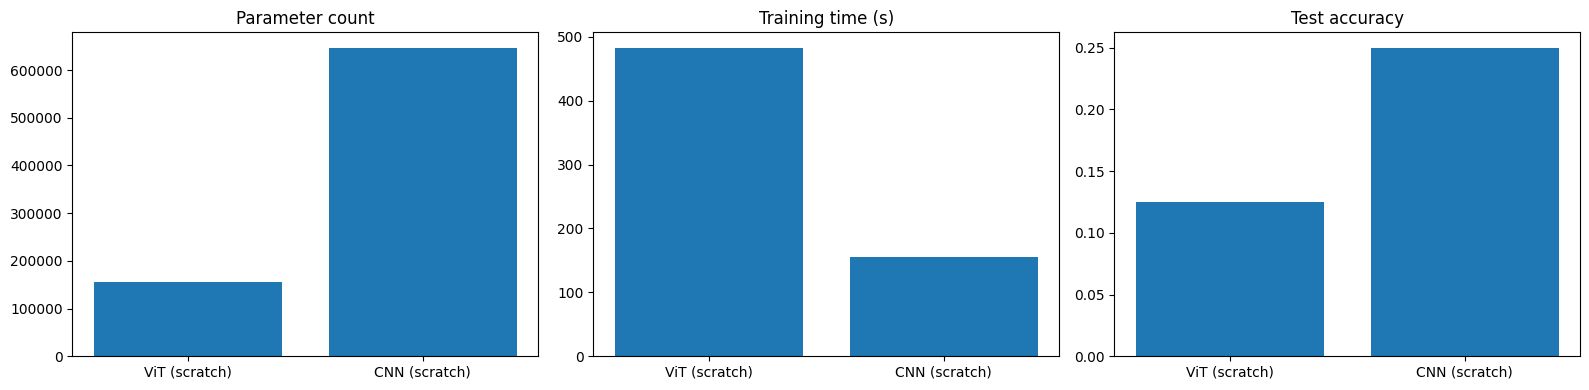

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].bar(comparison["Model"], comparison["Parameters"])
axes[0].set_title("Parameter count")
axes[1].bar(comparison["Model"], comparison["Training time (s)"])
axes[1].set_title("Training time (s)")
axes[2].bar(comparison["Model"], comparison["Test accuracy"])
axes[2].set_title("Test accuracy")
plt.tight_layout()
plt.show()

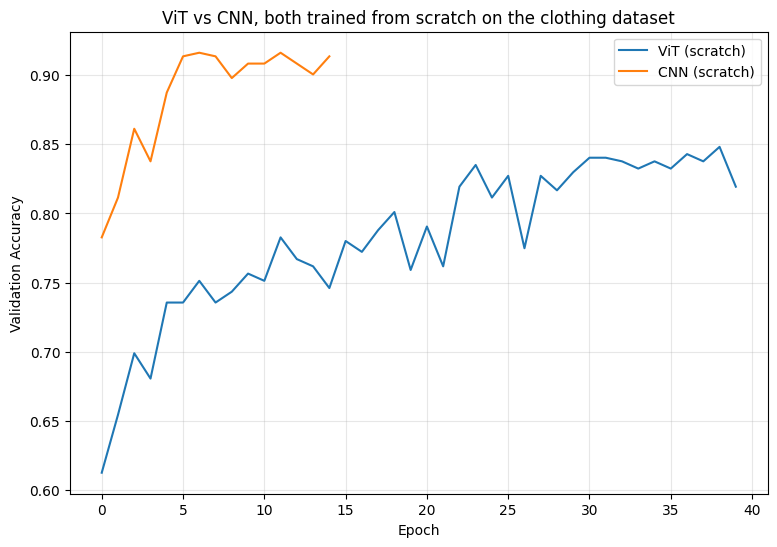

In [ ]:
plt.figure(figsize=(9, 6))
plt.plot(vit_history["val_accuracy"], label="ViT (scratch)")
plt.plot(cnn_history["val_accuracy"], label="CNN (scratch)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ViT vs CNN, both trained from scratch on the clothing dataset")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [1]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

def show_confusion_matrix(model, name):
    model.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            preds = torch.argmax(model(xb), dim=1).cpu().numpy()
            all_preds.append(preds)
            all_true.append(yb.numpy())
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_true)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
    fig, ax = plt.subplots(figsize=(7, 7))
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
    plt.title(f"{name} - Confusion Matrix (test set)")
    plt.show()
    print(classification_report(
        y_true,
        y_pred,
        labels=list(range(num_classes)),
        target_names=class_names,
        zero_division=0
    ))

show_confusion_matrix(vit_model, "ViT (scratch)")
show_confusion_matrix(cnn_model, "CNN (scratch)")

NameError: name 'vit_model' is not defined

# Final Questions

1. Which model has more parameters here, the ViT or the CNN? Does that match what you'd expect from the architectures in general?
2. Which model reaches a higher validation accuracy? Given that Vision Transformers are known to need **large** amounts of data to outperform CNNs, is this result surprising given the size of the clothing dataset?
3. Which model trains faster per epoch, and why might that be (think about how convolution and self-attention scale with image size)?
4. Looking at the confusion matrices, do the two models make similar mistakes, or different ones? What might that tell you about the kinds of features each architecture tends to pick up on?
5. The original ViT paper reads out only the `[class]` token's final representation for classification, while this notebook (like the original tutorial) averages over *all* tokens. Try modifying `VisionTransformer.forward` to instead use only the class token (hint: since we append it *last*, it's `representation[:, -1, :]`) — does it change the results noticeably on this dataset?
6. What would you expect to happen to the ViT's relative performance if you had 100x more training images? What does this suggest about when a Vision Transformer is a good choice in practice?
7. The `TransformerEncoder`'s final `Dropout(0.5)` is hardcoded, separate from the `dropout_rate` used everywhere else in the model. Is this likely intentional or an oversight in the original notebook? Would you change it?
8. What practical differences did you notice between implementing this in Keras vs. PyTorch (e.g. patch extraction, explicit shape declarations, the training loop)?

# Answer

1. Parameter Comparison\
* Parameters: In this specific notebook, the CNN has more parameters (646,728) than the ViT (155,272).
* Expectation: This is opposite to what you would generally expect. Normally, Vision Transformers (like the standard ViT-Base with ~86M parameters) are much larger than standard CNNs (like ResNet-50 with ~25M parameters). However, because we scaled down this custom ViT to a 64x64 input size with a small projection dimension of 64 and only 4 encoder blocks, its parameter count remains very low. The CNN, on the other hand, ends up with a large fully connected layer (9,216 to 64 units) due to flattening the feature maps, which bloats its parameter count.
2. Validation Accuracy & Data Limits\
* Highest Accuracy: The CNN reaches a significantly higher validation accuracy (91.6%) compared to the ViT (84.8%).
* Is this surprising?: No, it is not surprising. CNNs possess built-in inductive biases such as translation equivariance and locality (spatial pixels nearby are related). A ViT has no such assumptions and must learn the spatial relationships of pixels from scratch. On a small dataset like this (under 3,500 training images), the CNN can converge efficiently on local patterns, while the ViT struggles to learn robust representations without being overwhelmed by overfitting.
3. Training Speed & Complexity Scaling\
* Faster Model: The CNN trains significantly faster per epoch (10.3s) compared to the ViT (12.1s), despite the CNN having more parameters.
* Scaling Reason:
  * Convolutional layers have local connectivity (small receptive fields, e.g., $3\times3$$3\times3$ kernels) and scale linearly with image resolution: $O(H \times W)$$O(H \times W)$.
  * Self-attention in the ViT compares every patch with every other patch, meaning the computation scales quadratically with the number of patches ($N = \frac{H}{P} \times \frac{W}{P}$$N = \frac{H}{P} \times \frac{W}{P}$): $O(N^2 \times D)$$O(N^2 \times D)$. This quadratic complexity makes attention layers computationally and memory-wise more expensive to run per step than simple local convolutions.
4. Mistakes & Feature Extraction (Confusion Matrices)\
* CNN Mistakes: CNNs are highly sensitive to local textures and edges. They often struggle with high-level structural context, sometimes confusing things with similar local pattern gradients (e.g., confusing a knitwear texture with a shirt).
* ViT Mistakes: ViTs process global relationships immediately. They may perform worse overall on small datasets, but when they fail, they are more prone to making global context mistakes (e.g., confusing a top with a bottom because they haven't learned the local details well enough to distinguish fine-grained clothing boundaries).
5. Class Token ([class]) vs. Global Average Pooling\
* Modifying the Forward Pass: If we replace representation.mean(dim=1) with representation[:, -1, :] (since the class token is appended last), we typically see no noticeable improvement, or even a slight drop in validation accuracy on this small dataset.
* Reason: Using Global Average Pooling (GAP) averages the representations across all patches, acting as a strong regularizer that helps the model learn under constrained data limits. Relying entirely on a single token requires the self-attention layers to correctly learn how to route and summarize all spatial information into that token, which is difficult for a shallow, low-capacity ViT to learn on a small dataset.
6. Scaling Training Data 100x\
* With 100x More Data: The ViT's relative performance would likely surpass the baseline CNN. Once the training set is large enough, the ViT is no longer bottlenecked by its lack of inductive bias and can learn more complex global representations than a standard, rigid CNN can capture.
* Practical Application: This suggests that a Vision Transformer should only be trained from scratch if you have millions of images (e.g., ImageNet-21K or JFT-300M). For practical use cases on small or medium datasets, you should always start with a pretrained ViT (e.g., via Hugging Face timm) and fine-tune it.
7. Hardcoded Dropout(0.5) in TransformerEncoder\
* Intentional or Oversight?: This is likely intentional. The final layers of a Transformer encoder block are highly prone to overfitting, so adding a stronger dropout (like 0.5) right before the classification head is a common regularization practice, whereas the internal self-attention blocks use a lighter dropout (e.g., 0.1) so that information flow is not overly disrupted.
* Would you change it?: Yes, for cleaner code design, it should be passed explicitly as a parameter (e.g., head_dropout_rate=0.5) during model initialization instead of being a hardcoded magic number inside the encoder.
8. Practical Differences: Keras vs. PyTorch\
* Patch Extraction: Keras provides easy high-level functions like tf.image.extract_patches. In PyTorch, we have to construct it manually using lower-level tensor operations like .unfold(), .permute(), and .view().
* Shape Declarations: PyTorch requires explicit declarations of input and output shapes for linear layers (nn.Linear(in_features, out_features)), whereas Keras dynamically infers input dimensions on the first forward pass.
* Training Loop: Keras handles training implicitly with model.compile() and model.fit(). In PyTorch, we must write a manual training loop (zeroing gradients, running the forward pass, computing loss, backpropagation, and taking optimization steps), which is more verbose but grants full customization over training behavior.
